# 1. Experimental framework implementation

## Best practice to implement and test $n$ heuristics and $m$ objective functions?

* There are some common characteristics for the two most important _things_ in our framework
  * Heuristics - store the best found solution, manage stop criterion, etc.
  * Objective functions - store $f^*$, lower/upper bounds, etc.
* Every specific heuristic or obj. function implements its own search space exploration or evaluation, neighbourhood generation, etc.
* Thus, the object-oriented design should help us to separate these concerns as much as possible and also to keep us sane.

![OOP Design](../figures/interface.png)

## Example: two objective functions and generalized Shoot&Go


### Objective functions

#### 1. Recommender

* Same as on the previous class, i.e. we will **minimize** obj. function values
* implemented as ``class Recommender(ObjFun)`` in ``src/objfun_recommender.py``

In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', os.path.join('src')))

# Ensure modules are reloaded on any change (very useful when developing code on the fly)
%load_ext autoreload
%autoreload 2

In [2]:
from objfun_recommender import Recommender
recommender = Recommender()

In [3]:
recommender.get_bounds()

[array([0, 0]), array([99, 99])]

In [4]:
recommender.get_fstar()

0.0

In [5]:
recommender.generate_point()

array([93, 92])

In [6]:
recommender.evaluate([37, 68])

0.0

In [7]:
recommender.get_neighborhood([37, 68], 1)

[array([36, 67]),
 array([36, 68]),
 array([36, 69]),
 array([37, 67]),
 array([37, 69]),
 array([38, 67]),
 array([38, 68]),
 array([38, 69])]

### Generalized Shoot&Go: $\mathrm{SG}_{hmax}$

* Shoot & Go heuristic (also known as *Iterated Local Search*, *Random-restart hill climbing*, etc)
    * $hmax \in \{ 0, 1, \ldots, \infty \}$ parameter - maximum number of local searches / hill climbs
    * note that $\mathrm{SG}_{0}$ is pure Random Shooting (Random Search)
    
* implemented as ``class ShootAndGo(Heuristic)`` in ``src/heur_sg.py``    



In [8]:
from heur_sg import ShootAndGo

In [9]:
# Random Shooting for the AirShip initialization...
demo_rs = ShootAndGo(recommender, maxeval=100, hmax=0)
# ...and execution:
demo_rs.search()

{'best_y': 6.5, 'best_x': array([32, 67]), 'neval': 100, 'success': False}

# 2. Performance evaluation

## What is the recommended approach to store and analyze results of your experiments?

1. Append all relevant statistics from a single run into table (e.g. CSV file in memory or on disk), including all task and heuristic parameters 
2. Load the table into analytical tool of your choice (**data frame**, Excel or Google Docs spreadsheets, etc.)
3. Pivot by relevant parameters, visualize in tables or charts

## Demonstration

Neccessary setup first:

In [10]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

### General experiment setup

Runs selected objective function (`of`) using selected heuristic multiple times, stores and returns data (results) in a data frame.

In [11]:
def experiment(of, num_runs, hmax):
    results = []
    for i in tqdm(range(num_runs), 'Testing hmax = {}'.format(hmax)):
        result = ShootAndGo(of, maxeval=100, hmax=hmax, seed=i).search() # dict with results of one run
        result['run'] = i
        result['heur'] = 'SG_{}'.format(hmax) # name of the heuristic
        result['hmax'] = hmax
        results.append(result)
    return pd.DataFrame(results, columns=['heur', 'run', 'hmax', 'best_x', 'best_y', 'neval', 'success'])

### Recommender experiments

In [12]:
table = pd.DataFrame()
for hmax in [0, 1, 2, 5, 10, 20, 50, np.inf]:
    res = experiment(recommender, 10_000, hmax)
    table = pd.concat([table, res], axis=0)

Testing hmax = 0:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing hmax = 1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing hmax = 2:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing hmax = 5:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing hmax = 10:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing hmax = 20:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing hmax = 50:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing hmax = inf:   0%|          | 0/10000 [00:00<?, ?it/s]

In [13]:
table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   heur     80000 non-null  object 
 1   run      80000 non-null  int64  
 2   hmax     80000 non-null  float64
 3   best_x   80000 non-null  object 
 4   best_y   80000 non-null  float64
 5   neval    80000 non-null  int64  
 6   success  80000 non-null  bool   
dtypes: bool(1), float64(2), int64(2), object(2)
memory usage: 4.3+ MB


In [14]:
table.head()

,heur,run,hmax,best_x,best_y,neval,success
0,SG_0,0,0.0,"[37, 68]",0.00,29,True
1,SG_0,1,0.0,"[36, 63]",6.50,100,False
2,SG_0,2,0.0,"[33, 60]",20.00,100,False
3,SG_0,3,0.0,"[31, 64]",13.00,100,False
4,SG_0,4,0.0,"[30, 70]",13.25,100,False


#### What is the quality of solutions based on `hmax`?

In **tabular** form:

In [15]:
table.groupby(['hmax'])['best_y'].median()

hmax
0.0      6.25
1.0     25.15
2.0     31.50
5.0     40.50
10.0    43.35
20.0    49.00
50.0    49.00
inf     49.00
Name: best_y, dtype: float64

In [16]:
table.groupby(['hmax'])['best_y'].mean()

hmax
0.0       7.556415
1.0      29.012200
2.0      42.902780
5.0      66.306115
10.0     84.961000
20.0    128.471755
50.0    128.471755
inf     128.471755
Name: best_y, dtype: float64

Random Shooting seems to find highest quality on average. Feel free to compute other statistics instead of median and mean.

Directly as **Box-Whiskers plot**:

In [17]:
# import visualization libraries
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

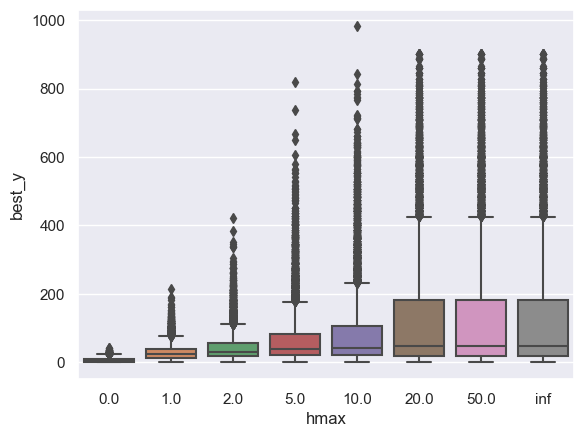

In [18]:
sns.boxplot(x="hmax", y="best_y", data=table);

#### Number of evaluations (when successful), based on `hmax`?

`success` is reported directly by the heuristic:

In [19]:
table.head()

,heur,run,hmax,best_x,best_y,neval,success
0,SG_0,0,0.0,"[37, 68]",0.00,29,True
1,SG_0,1,0.0,"[36, 63]",6.50,100,False
2,SG_0,2,0.0,"[33, 60]",20.00,100,False
3,SG_0,3,0.0,"[31, 64]",13.00,100,False
4,SG_0,4,0.0,"[30, 70]",13.25,100,False


In [20]:
table[table['success']].head()

,heur,run,hmax,best_x,best_y,neval,success
0,SG_0,0,0.0,"[37, 68]",0.0,29,True
49,SG_0,49,0.0,"[37, 68]",0.0,41,True
96,SG_0,96,0.0,"[37, 68]",0.0,61,True
183,SG_0,183,0.0,"[37, 68]",0.0,100,True
206,SG_0,206,0.0,"[37, 68]",0.0,29,True


Table:

In [21]:
table[table['success']].groupby(['hmax'])['neval'].mean()

hmax
0.0     48.645161
1.0     54.066667
2.0     52.350000
5.0     52.413655
10.0    55.288421
20.0    65.744838
50.0    65.744838
inf     65.744838
Name: neval, dtype: float64

In [22]:
table[table['success']].groupby(['hmax'])['neval'].median()

hmax
0.0     45.5
1.0     53.5
2.0     50.0
5.0     60.0
10.0    59.0
20.0    69.5
50.0    69.5
inf     69.5
Name: neval, dtype: float64

Shorter runs seem to be the _quickest_.

Graphically:

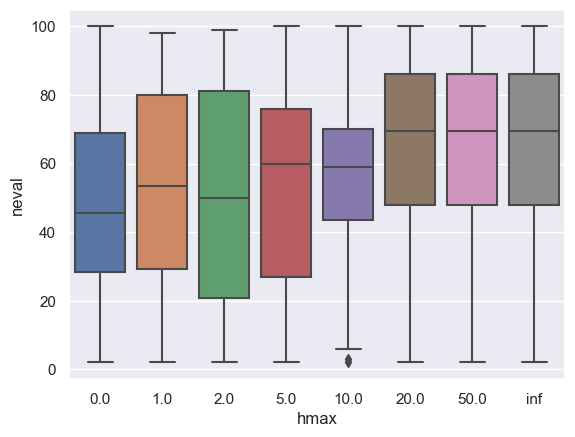

In [23]:
sns.boxplot(x="hmax", y="neval", data=table[table['success'] == True]);

#### Reliability

In [24]:
rel_by_hmax = table.pivot_table(
    index=['hmax'],
    values=['success'],
    aggfunc='mean'
)

In [25]:
rel_by_hmax

,success
hmax,
0.0,0.0124
1.0,0.0090
2.0,0.0140
5.0,0.0249
10.0,0.0475
20.0,0.0678
50.0,0.0678
inf,0.0678


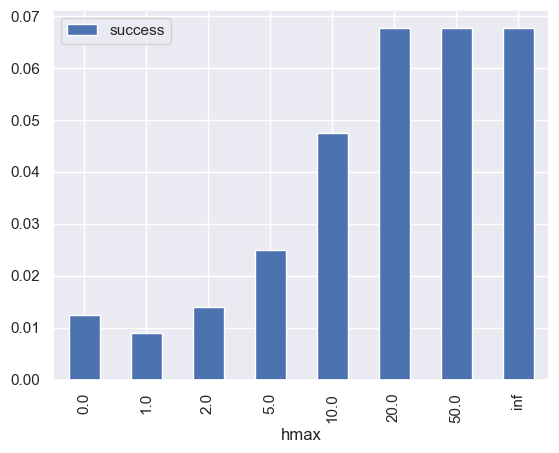

In [26]:
rel_by_hmax.plot(kind='bar');

We can conclude that longer runs (almost unlimited) are the most reliable, on average.

#### Speed, normalized by reliability?

* Reliability: $REL = m/q$ where $m$ is number of successful runs and $q$ is total number of runs, $REL \in [0, 1]$
* Mean Number of objective function Evaluations: $MNE = \frac{1}{m} \sum_{i=1}^m neval_i$
* Feoktistov criterion: $FEO = MNE/REL$

In [27]:
mne = table[table['success']].groupby('hmax')['neval'].mean()
rel = table.groupby('hmax')['success'].mean()
feo_by_hmax = (mne / rel).rename('neval').to_frame()

In [28]:
feo_by_hmax

,neval
hmax,
0.0,3922.996878
1.0,6007.407407
2.0,3739.285714
5.0,2104.966049
10.0,1163.966759
20.0,969.687873
50.0,969.687873
inf,969.687873


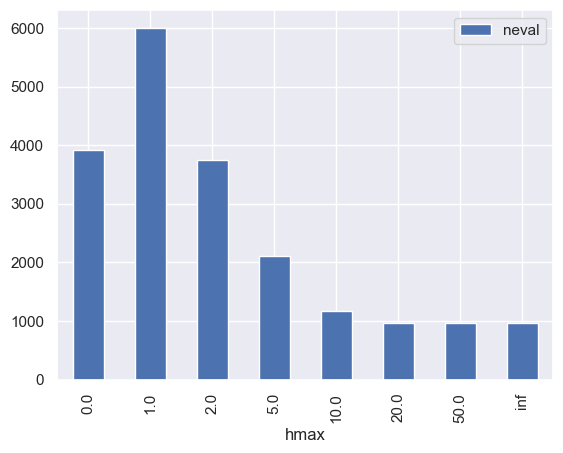

In [29]:
feo_by_hmax.plot(kind='bar');

After normalization by reliability, it seems that very long run (almost infinitely) is the _fastest_.

> **Note:** `hmax = 20`, `50`, and `∞` produce identical results across all metrics. This is expected: steepest descent is fully deterministic once the starting point is fixed (no `random_descent`), so the same seed always yields the same trajectory. The data is telling us that for every starting point in this 100×100 grid, the descent converges in fewer than 20 steps — meaning more hill-climbing budget beyond that buys nothing. This is a property of the objective function's landscape, not a bug.

# Assignments (or rather inspiration for your own work)

1. Implement your heuristics from the previous class, using this frammework; couple ideas:
   1. **Random Descent**, similar to Shoot & Go, but does not follow steepest descent, chooses direction of the descent randomly instead
   1. **Taboo Search**
1. Experiment with **neighbourhood diameter** `d` in `Recommender.get_neighborhood(x, d)`
1. Think what issues you see with this design